### Final project

>problem statement- Predicting House price(california)


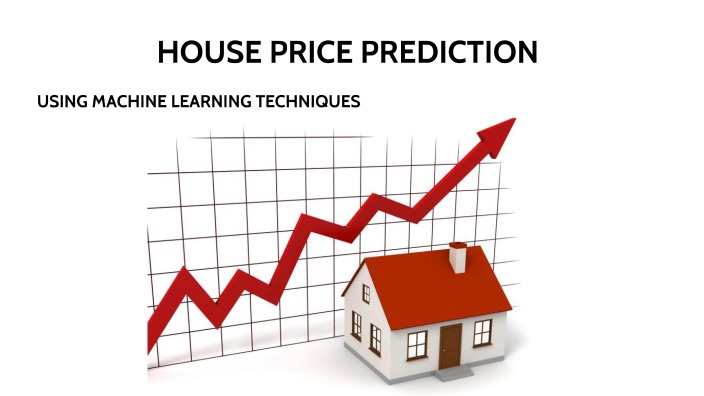


House Price Prediction ProjecCaliforniat

### Objective
> The objective of this project is to build a multiple linear regression model that predicts the median house value in California districts based on various features like median income, housing median age, and average room counts.

#### Machine Learning Pipeline

* Data Collection and Import
* Exploratory Data Analysis & Data Cleaning (Handling Nulls and Duplicates)
* Feature Selection & Data Splitting
* Feature Scaling (Standardization)
* Model Building & Training
* Model Evaluation

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Data Collection and Import
# Load the dataset from a URL or local file path

In [4]:
data_url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(data_url)

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.shape

(20640, 10)

> in the feature called "Total_Bedroom" we have null value we need to fix it(mean/median)

In [8]:
## checking Dupilicate

duplicates=df.duplicated().sum()
print("Number of duplicate rows:" +str(duplicates))

Number of duplicate rows:0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
# Handle missing values: Fill missing 'total_bedrooms' with the median of that column
median_bedrooms = df["total_bedrooms"].median()
median_bedrooms

435.0

In [11]:
df["total_bedrooms"].isnull().sum()

np.int64(207)

In [12]:

df.fillna(median_bedrooms, inplace=True)

In [14]:
df["total_bedrooms"].isnull().sum()

np.int64(0)

In [13]:
### Enhancing the Model: One-Hot Encoding and Feature Engineering

# Apply one-hot encoding to 'ocean_proximity'
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [15]:
df_encoded.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

>Done with data prepartion

>>Creating new features based on other features(columns)

In [16]:
# Create new features
df_encoded['rooms_per_household'] = df_encoded['total_rooms'] / df_encoded['households']
df_encoded['bedrooms_per_room'] = df_encoded['total_bedrooms'] / df_encoded['total_rooms']
df_encoded['population_per_household'] = df_encoded['population'] / df_encoded['households']

df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False,6.281853,0.172096,2.181467


##### vertically split(to seperate input and output)

In [17]:
X=df_encoded.drop(columns = "median_house_value") #i/p dataset


In [18]:
X.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN',
       'rooms_per_household', 'bedrooms_per_room', 'population_per_household'],
      dtype='object')

In [20]:
Y=df_encoded['median_house_value'] #o/p

#### Horizontal splitting(train,test)

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
# Split the data into training (80%) and testing (20%) sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X,Y, test_size=0.2, random_state=42)

In [23]:
X_train_new

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,False,False,False,True,5.017657,0.200576,3.691814
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,False,False,False,True,4.473545,0.232703,1.738095
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,False,False,False,True,5.645833,0.174486,2.723214
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,False,False,False,True,4.002817,0.258269,3.994366
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,True,False,False,False,6.268421,0.180940,2.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,False,False,False,False,6.129032,0.151128,3.032258
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,True,False,False,False,6.868597,0.184825,3.904232
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,False,False,False,False,3.986717,0.270823,3.332068
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,False,False,False,False,6.395349,0.166993,3.178891


#### we need to standardisation

In [24]:
from sklearn.preprocessing import StandardScaler
# Initialize the StandardScaler
scaler_new = StandardScaler()

# Fit and transform the training features
X_train_scaled_new = scaler_new.fit_transform(X_train_new) ## mean and sd

# Transform the testing features using the training set scaler
X_test_scaled_new = scaler_new.transform(X_test_new) # mean and sd

In [25]:
### use regression model

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [26]:
lr.fit(X_train_scaled_new,y_train_new)

LinearRegression()

In [27]:
y_predict = lr.predict(X_test_scaled_new)

In [28]:
### model evaluation
from sklearn.metrics import r2_score,root_mean_squared_error
print("RMSE:",root_mean_squared_error(y_test_new,y_predict))
print("R2_Score:",r2_score(y_test_new,y_predict))

RMSE: 72668.53837868226
R2_Score: 0.5970176824350761


>> This is not good model

### Random Forest Regressor

>Ensemble learing algorithm

>model used =  Decision Tree

>for classification - majority

>for regression - average

<img src="https://www.slideteam.net/media/catalog/product/cache/1280x720/f/r/framework_of_random_forest_regression_algorithm_ppt_sample_slide01.jpg">

In [29]:
## Change the model to RandomForesetRegression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled_new,y_train_new)
rfpredict = rf.predict(X_test_scaled_new)
print("RMSE:",root_mean_squared_error(y_test_new,rfpredict))
print("R2_Score:",r2_score(y_test_new,rfpredict))

RMSE: 50258.94749355783
R2_Score: 0.807238667843144


>> Random Forest  Regressor has higher performance compare to Linear Regression

In [30]:
import pickle

pickle.dump(rf,open("model.pkl","wb"))